# LDTF-BERT - Member 4 tổng hợp và phân tích

Notebook này không train và không đọc tập test. Member 4 nhận thủ công ba file ZIP từ Member 1, 2, 3, upload vào `incoming/`, rồi **Run all**. Notebook kiểm tra đủ 6 model cùng seed 42, đối chiếu protocol, xếp hạng validation, so sánh với B2 và tạo báo cáo trực quan trên Drive.


## 1. Kết nối Drive và chuẩn bị môi trường

In [1]:
from google.colab import drive
from tqdm.auto import tqdm

with tqdm(total=4, desc="Chuẩn bị Member 4", unit="bước") as progress:
    progress.set_postfix_str("Trạng thái: đang kết nối Drive")
    drive.mount("/content/drive")
    progress.update(1)
    import hashlib, json, os, shutil, subprocess, sys, zipfile
    from pathlib import Path
    MEMBER_ROOT = Path("/content/drive/MyDrive/LDTF_4_MEMBERS")
    SOURCE_ARCHIVE = MEMBER_ROOT / "source" / "LDTF_bert_source.zip"
    INCOMING_ROOT = MEMBER_ROOT / "incoming"
    RESULTS_ROOT = MEMBER_ROOT / "results" / "multisource_v1_core_seed42_split3"
    INCOMING_ROOT.mkdir(parents=True, exist_ok=True)
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    assert SOURCE_ARCHIVE.is_file(), f"Thiếu source ZIP: {SOURCE_ARCHIVE}"
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang giải nén source")
    EXTRACT_ROOT = Path("/content/ldtf_source_member4")
    if EXTRACT_ROOT.exists():
        shutil.rmtree(EXTRACT_ROOT)
    EXTRACT_ROOT.mkdir(parents=True)
    with zipfile.ZipFile(SOURCE_ARCHIVE) as archive:
        root = EXTRACT_ROOT.resolve()
        members = archive.infolist()
        for item in members:
            target = (EXTRACT_ROOT / item.filename).resolve()
            assert target == root or root in target.parents, f"ZIP không an toàn: {item.filename}"
        for item in tqdm(members, desc="Giải nén source", unit="file", leave=False):
            archive.extract(item, EXTRACT_ROOT)
    PROJECT = next(p for p in [EXTRACT_ROOT] + [x for x in EXTRACT_ROOT.iterdir() if x.is_dir()] if (p / "src").is_dir())
    os.chdir(PROJECT)
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang cài thư viện")
    print("Đang cài thư viện phân tích.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(PROJECT / "requirements.txt")], check=True)
    progress.update(1)
    progress.set_postfix_str("Trạng thái: hoàn tất", refresh=True)
print("Project:", PROJECT)


Chuẩn bị Member 4:   0%|          | 0/4 [00:00<?, ?bước/s]

Mounted at /content/drive


Giải nén source:   0%|          | 0/34 [00:00<?, ?file/s]

Đang cài thư viện phân tích.
Project: /content/ldtf_source_member4/LDTF_bert_source


## 2. Đọc protocol và nhận ba gói kết quả

In [2]:
from tqdm.auto import tqdm

with tqdm(total=3, desc="Đọc protocol", unit="bước") as progress:
    progress.set_postfix_str("Trạng thái: đang đọc config")
    CONFIG_PATH = PROJECT / "configs" / "colab_4_members.json"
    TEAM_CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
    CONFIG_SHA256 = hashlib.sha256(CONFIG_PATH.read_bytes()).hexdigest()
    protocol = TEAM_CONFIG["protocol"]
    dataset_cfg = TEAM_CONFIG["dataset"]
    RESULTS_ROOT = MEMBER_ROOT / TEAM_CONFIG["storage"]["results_subdir"]
    ANALYSIS_ROOT = MEMBER_ROOT / TEAM_CONFIG["storage"]["analysis_subdir"]
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang kiểm tra 3 ZIP")
    trainers = [(int(mid), int(info["seed"]), list(info["assigned_runs"])) for mid, info in TEAM_CONFIG["members"].items() if info["role"] == "trainer"]
    expected_bundles = [f"member_{mid}_seed{seed}_summaries.zip" for mid, seed, _runs in trainers]
    missing = [name for name in expected_bundles if not (INCOMING_ROOT / name).is_file()]
    progress.update(1)
    if missing:
        progress.set_postfix_str("Trạng thái: đang chờ upload ZIP")
        from google.colab import files
        print("Chọn đúng các file còn thiếu:", missing)
        uploaded = files.upload()
        for filename in tqdm(uploaded, desc="Lưu ZIP lên Drive", unit="file", leave=False):
            assert filename in missing, f"Tên file không thuộc danh sách cần nhận: {filename}"
            (INCOMING_ROOT / filename).write_bytes(uploaded[filename])
    remaining = [name for name in expected_bundles if not (INCOMING_ROOT / name).is_file()]
    assert not remaining, f"Vẫn thiếu: {remaining}"
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đã nhận đủ 3 ZIP", refresh=True)
print("Đã nhận đủ 3 ZIP:", expected_bundles)


Đọc protocol:   0%|          | 0/3 [00:00<?, ?bước/s]

Đã nhận đủ 3 ZIP: ['member_1_seed42_summaries.zip', 'member_2_seed42_summaries.zip', 'member_3_seed42_summaries.zip']


## 3. Nhập kết quả và kiểm tra an toàn

In [3]:
from tqdm.auto import tqdm

with tqdm(expected_bundles, desc="Nhập kết quả", unit="ZIP") as progress:
    for filename in progress:
        progress.set_postfix_str(f"Trạng thái: đang nhập {filename}")
        bundle = INCOMING_ROOT / filename
        with zipfile.ZipFile(bundle) as archive:
            root = RESULTS_ROOT.resolve()
            for item in archive.infolist():
                target = (RESULTS_ROOT / item.filename).resolve()
                assert target == root or root in target.parents, f"Đường dẫn không an toàn trong {filename}"
            for item in tqdm(archive.infolist(), desc=filename, unit="file", leave=False):
                archive.extract(item, RESULTS_ROOT)
    progress.set_postfix_str("Trạng thái: hoàn tất", refresh=True)
print("Đã nhập ba gói vào:", RESULTS_ROOT)


Nhập kết quả:   0%|          | 0/3 [00:00<?, ?ZIP/s]

member_1_seed42_summaries.zip:   0%|          | 0/8 [00:00<?, ?file/s]

member_2_seed42_summaries.zip:   0%|          | 0/8 [00:00<?, ?file/s]

member_3_seed42_summaries.zip:   0%|          | 0/8 [00:00<?, ?file/s]

Đã nhập ba gói vào: /content/drive/MyDrive/LDTF_4_MEMBERS/results/multisource_v1_core_seed42_split3


## 4. Kiểm tra đủ 6 model và đúng protocol

In [4]:
from tqdm.auto import tqdm
import pandas as pd

expected_jobs = [(mid, run, seed) for mid, seed, assigned_runs in trainers for run in assigned_runs]
assert len(expected_jobs) == 6 and {run for _mid, run, _seed in expected_jobs} == set(protocol["runs"])
status_rows, result_rows, violations = [], [], []
source_hashes, config_hashes = set(), set()
with tqdm(expected_jobs, desc="Kiểm tra protocol", unit="job") as progress:
 for member_id, run_name, seed in progress:
    progress.set_postfix_str(f"Trạng thái: đang kiểm tra {run_name}, seed {seed}")
    run_label = f"{run_name}_seed{seed}"
    run_dir = RESULTS_ROOT / run_label
    summary_path = run_dir / "run_summary.json"
    metadata_path = run_dir / "team_job_metadata.json"
    status = "complete" if summary_path.exists() and metadata_path.exists() else ("incomplete" if run_dir.exists() else "missing")
    status_rows.append({"member_id": member_id, "run": run_name, "seed": seed, "status": status})
    if status != "complete":
        continue
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    runtime, signature = summary.get("runtime", {}), summary.get("data_signature", {})
    checks = {
        "đúng_model": summary.get("base_run") == run_name,
        "đúng_seed": summary.get("seed") == seed,
        "đủ_dữ_liệu": not summary.get("is_debug_subset", True) and summary.get("train_rows") == dataset_cfg["expected_rows"]["train"],
        "đúng_train_hash": signature.get("train_sha256") == dataset_cfg["sha256"][dataset_cfg["train_file"]],
        "đúng_validation_hash": signature.get("validation_sha256") == dataset_cfg["sha256"][dataset_cfg["validation_file"]],
        "đúng_epoch": summary.get("epochs") == protocol["epochs"],
        "đúng_batch": runtime.get("global_batch_size") == protocol["batch_size"],
        "đúng_eval_batch": runtime.get("global_eval_batch_size") == protocol["eval_batch_size"],
        "một_gpu": runtime.get("world_size") == 1,
        "deterministic": runtime.get("deterministic") is True,
        "amp": runtime.get("amp") is True,
        "gpu_t4": any("T4" in str(device).upper() for device in runtime.get("devices", [])),
        "đúng_padding": runtime.get("pad_to_multiple_of") == protocol["pad_to_multiple_of"],
        "metadata_complete": metadata.get("status") == "complete",
        "đúng_member": metadata.get("member_id") == member_id,
        "đúng_config": metadata.get("config_sha256") == CONFIG_SHA256,
        "có_source_hash": bool(metadata.get("source_archive_sha256")),
    }
    failed = [name for name, passed in checks.items() if not passed]
    if failed:
        violations.append({"job": run_label, "failed_checks": ", ".join(failed)})
    if metadata.get("source_archive_sha256"):
        source_hashes.add(metadata["source_archive_sha256"])
    if metadata.get("config_sha256"):
        config_hashes.add(metadata["config_sha256"])
    result_rows.append({"member_id": member_id, "run": run_name, "seed": seed, "best_epoch": summary["best_epoch"], "val_f1_macro": summary["best_val_f1_macro"], "val_accuracy": summary["best_val_accuracy"], "val_loss": summary["best_val_loss"], "train_hours": summary["total_train_seconds"] / 3600, "peak_vram_gb": summary["peak_vram_gb"], "protocol_ok": not failed})
 progress.set_postfix_str("Trạng thái: hoàn tất", refresh=True)

if len(source_hashes) != 1:
    violations.append({"job": "_team", "failed_checks": "không dùng duy nhất một source ZIP"})
if config_hashes != {CONFIG_SHA256}:
    violations.append({"job": "_team", "failed_checks": "config bị trộn hoặc đã cũ"})
status_df = pd.DataFrame(status_rows)
raw_df = pd.DataFrame(result_rows)
violations_df = pd.DataFrame(violations)
display(status_df)
print(f"Hoàn thành: {(status_df.status == 'complete').sum()}/{len(status_df)}; vi phạm: {len(violations)}")
if not violations_df.empty:
    display(violations_df)


Kiểm tra protocol:   0%|          | 0/6 [00:00<?, ?job/s]

,member_id,run,seed,status
0,1,B2_bert_finetuned_cls,42,complete
1,1,A0,42,complete
2,2,A1,42,complete
3,2,A3,42,complete
4,3,A4,42,complete
5,3,A11,42,complete


Hoàn thành: 6/6; vi phạm: 0


## 5. Xếp hạng 6 model trên seed 42

In [5]:
from tqdm.auto import tqdm
import numpy as np

with tqdm(total=4, desc="Tính thống kê", unit="bước") as progress:
    progress.set_postfix_str("Trạng thái: đang lưu dữ liệu gốc")
    status_df.to_csv(ANALYSIS_ROOT / "job_status.csv", index=False)
    raw_df.to_csv(ANALYSIS_ROOT / "validation_by_model.csv", index=False)
    violations_df.to_json(ANALYSIS_ROOT / "protocol_violations.json", orient="records", force_ascii=False, indent=2)
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang xếp hạng Macro F1")
    assert len(raw_df) == len(expected_jobs), "Chưa đủ 6 model nên chưa thể kết luận cuối"
    ranking_df = raw_df[["member_id", "run", "seed", "best_epoch", "val_f1_macro", "val_accuracy", "val_loss", "train_hours", "peak_vram_gb", "protocol_ok"]].sort_values(["val_f1_macro", "val_loss"], ascending=[False, True]).reset_index(drop=True)
    ranking_df.insert(0, "rank", np.arange(1, len(ranking_df) + 1))
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang so sánh với B2")
    baseline = "B2_bert_finetuned_cls"
    baseline_f1 = float(raw_df.loc[raw_df["run"] == baseline, "val_f1_macro"].iloc[0])
    delta_df = ranking_df.loc[ranking_df["run"] != baseline, ["run", "val_f1_macro"]].copy()
    delta_df["delta_f1_vs_B2"] = delta_df["val_f1_macro"] - baseline_f1
    delta_df = delta_df.sort_values("delta_f1_vs_B2", ascending=False).reset_index(drop=True)
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang lưu bảng tổng hợp")
    ranking_df.to_csv(ANALYSIS_ROOT / "validation_ranking.csv", index=False)
    delta_df.to_csv(ANALYSIS_ROOT / "delta_vs_B2.csv", index=False)
    progress.update(1)
    progress.set_postfix_str("Trạng thái: hoàn tất", refresh=True)
display(ranking_df)
display(delta_df)


Tính thống kê:   0%|          | 0/4 [00:00<?, ?bước/s]

,rank,member_id,run,seed,best_epoch,val_f1_macro,val_accuracy,val_loss,train_hours,peak_vram_gb,protocol_ok
0,1,1,B2_bert_finetuned_cls,42,3,0.948616,0.948626,0.188012,2.157642,3.9938,True
1,2,3,A11,42,3,0.947809,0.947874,0.185183,2.463422,4.1820,True
2,3,1,A0,42,3,0.947372,0.947373,0.188514,2.277578,4.1863,True
3,4,2,A3,42,3,0.946808,0.946872,0.188776,2.344108,4.1804,True
4,5,2,A1,42,3,0.945998,0.946036,0.190123,2.334453,4.1804,True
5,6,3,A4,42,2,0.945641,0.945702,0.175381,2.348097,4.1805,True


,run,val_f1_macro,delta_f1_vs_B2
0,A11,0.947809,-0.000807
1,A0,0.947372,-0.001244
2,A3,0.946808,-0.001808
3,A1,0.945998,-0.002618
4,A4,0.945641,-0.002975


## 6. Trực quan hóa kết quả

Vẽ biểu đồ:   0%|          | 0/4 [00:00<?, ?biểu đồ/s]

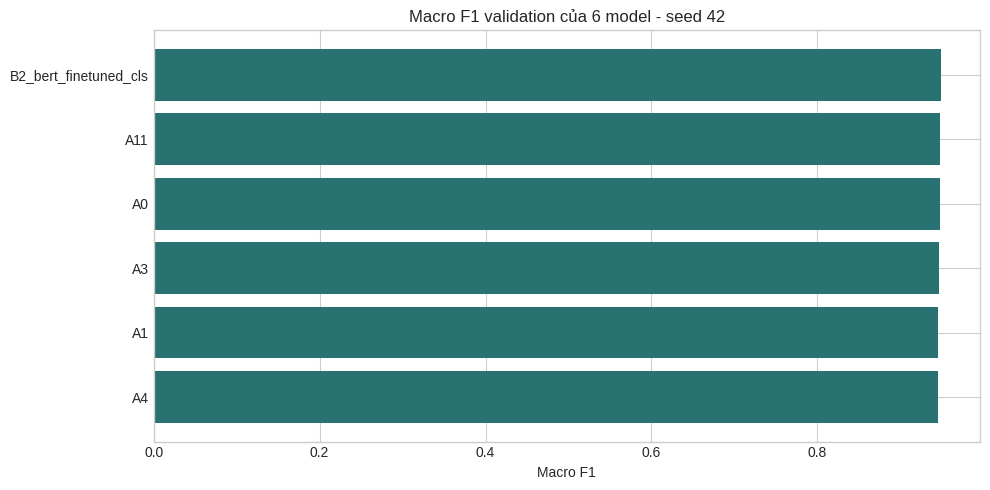

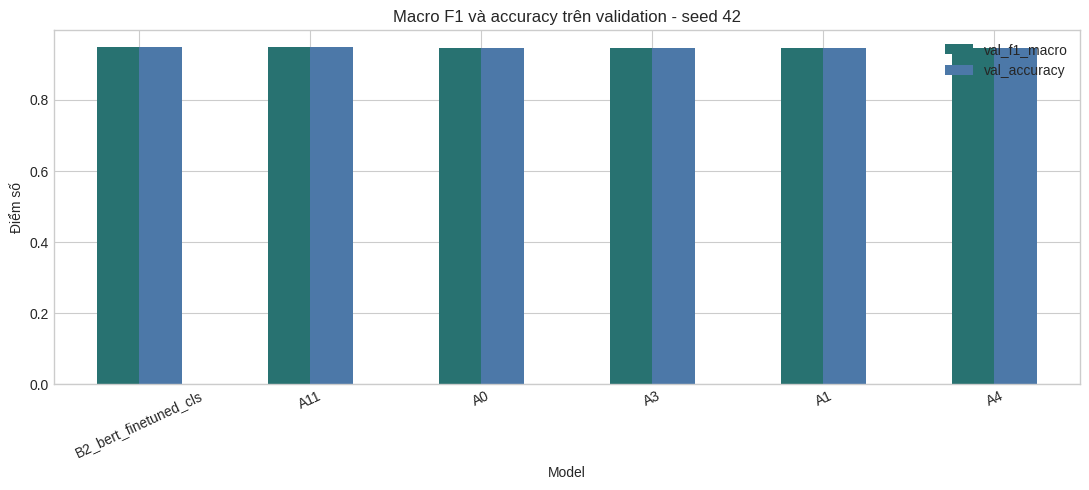

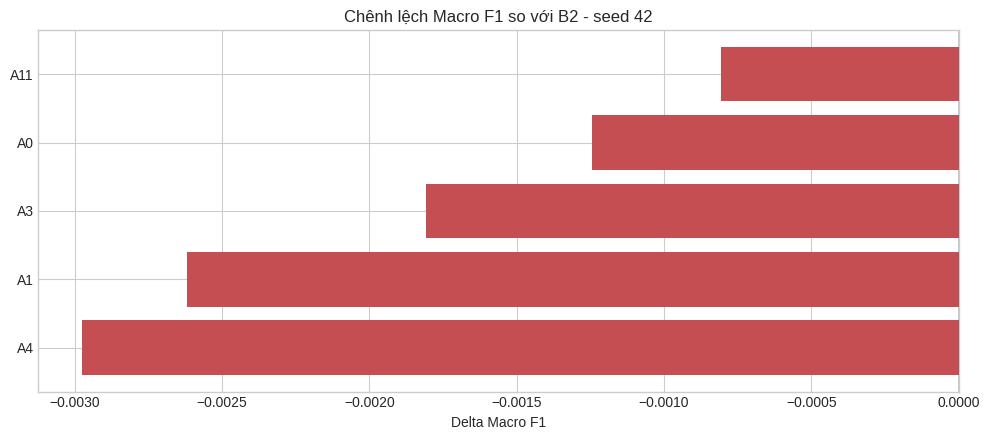

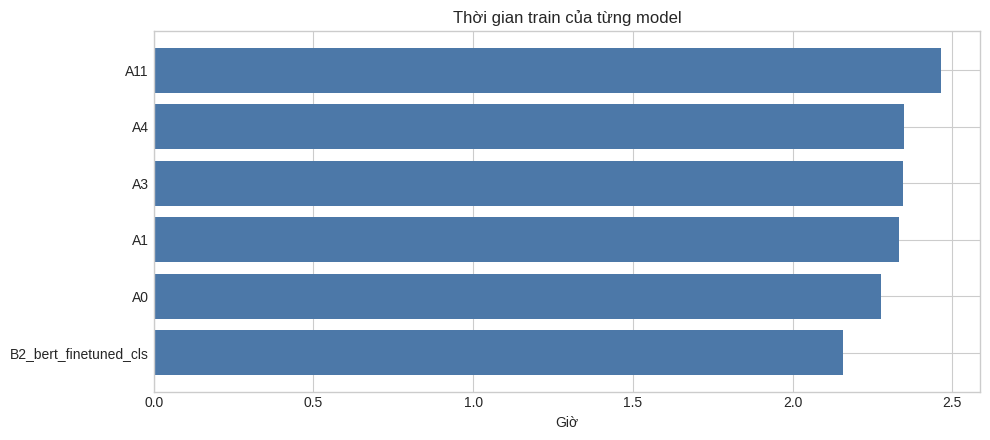

Đã lưu: ['01_validation_f1.png', '02_f1_accuracy.png', '03_delta_vs_B2.png', '04_runtime_hours.png']


In [6]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plots = []
with tqdm(total=4, desc="Vẽ biểu đồ", unit="biểu đồ") as progress:
    progress.set_postfix_str("Trạng thái: đang vẽ Macro F1")
    ordered = ranking_df.sort_values("val_f1_macro")
    fig, ax = plt.subplots(figsize=(10, 5)); ax.barh(ordered.run, ordered.val_f1_macro, color="#287271"); ax.set(title="Macro F1 validation của 6 model - seed 42", xlabel="Macro F1"); fig.tight_layout(); path = ANALYSIS_ROOT / "01_validation_f1.png"; fig.savefig(path, dpi=180); plots.append(path); plt.show(); progress.update(1)
    progress.set_postfix_str("Trạng thái: đang so sánh F1 và accuracy")
    metric_plot = ranking_df.set_index("run")[["val_f1_macro", "val_accuracy"]].sort_values("val_f1_macro", ascending=False)
    fig, ax = plt.subplots(figsize=(11, 5)); metric_plot.plot(kind="bar", ax=ax, color=["#287271", "#4c78a8"]); ax.set(title="Macro F1 và accuracy trên validation - seed 42", xlabel="Model", ylabel="Điểm số"); ax.tick_params(axis="x", rotation=25); fig.tight_layout(); path = ANALYSIS_ROOT / "02_f1_accuracy.png"; fig.savefig(path, dpi=180); plots.append(path); plt.show(); progress.update(1)
    progress.set_postfix_str("Trạng thái: đang vẽ delta với B2")
    ordered_delta = delta_df.sort_values("delta_f1_vs_B2"); colors = ["#c44e52" if value < 0 else "#287271" for value in ordered_delta.delta_f1_vs_B2]; fig, ax = plt.subplots(figsize=(10, 4.5)); ax.barh(ordered_delta.run, ordered_delta.delta_f1_vs_B2, color=colors); ax.axvline(0, color="black", linewidth=1); ax.set(title="Chênh lệch Macro F1 so với B2 - seed 42", xlabel="Delta Macro F1"); fig.tight_layout(); path = ANALYSIS_ROOT / "03_delta_vs_B2.png"; fig.savefig(path, dpi=180); plots.append(path); plt.show(); progress.update(1)
    progress.set_postfix_str("Trạng thái: đang vẽ thời gian train")
    runtime = ranking_df.sort_values("train_hours"); fig, ax = plt.subplots(figsize=(10, 4.5)); ax.barh(runtime.run, runtime.train_hours, color="#4c78a8"); ax.set(title="Thời gian train của từng model", xlabel="Giờ"); fig.tight_layout(); path = ANALYSIS_ROOT / "04_runtime_hours.png"; fig.savefig(path, dpi=180); plots.append(path); plt.show(); progress.update(1)
    progress.set_postfix_str("Trạng thái: hoàn tất", refresh=True)
print("Đã lưu:", [path.name for path in plots])


## 7. Xuất báo cáo kết luận

In [7]:
from tqdm.auto import tqdm

def markdown_table(frame):
    view = frame.copy()
    for column in view.select_dtypes(include="number").columns:
        view[column] = view[column].map(lambda value: "" if pd.isna(value) else f"{value:.6f}")
    lines = ["| " + " | ".join(map(str, view.columns)) + " |", "| " + " | ".join(["---"] * len(view.columns)) + " |"]
    lines.extend("| " + " | ".join(row) + " |" for row in view.astype(str).itertuples(index=False, name=None))
    return "\n".join(lines)

with tqdm(total=3, desc="Viết báo cáo", unit="phần") as progress:
    progress.set_postfix_str("Trạng thái: đang chọn model dẫn đầu")
    winner = ranking_df.iloc[0]
    ready = len(violations) == 0 and len(raw_df) == len(expected_jobs) == 6
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang tạo nội dung báo cáo")
    report = ["# Báo cáo validation 6 model - seed 42", "", f"- Trạng thái protocol: **{'ĐẠT' if ready else 'CHƯA ĐẠT'}**", f"- Model hoàn thành: **{len(raw_df)}/{len(expected_jobs)}**", f"- Model đứng đầu theo Macro F1: **{winner['run']}** ({winner['val_f1_macro']:.6f})", "- Seed dùng chung: **42**", "- Tập test: **chưa sử dụng**", "", "## Xếp hạng validation", "", markdown_table(ranking_df), "", "## Chênh lệch so với B2", "", markdown_table(delta_df), "", "## Cách đọc", "", "Macro F1 cao hơn thể hiện model phân loại cân bằng hơn giữa bốn nhãn. Delta dương nghĩa là model tốt hơn B2 trên cùng seed 42. Vì mỗi model chỉ chạy một seed, báo cáo này chưa đo được độ ổn định khi đổi seed.", "", "## Biểu đồ", "", "- `01_validation_f1.png`: Macro F1 của 6 model.", "- `02_f1_accuracy.png`: so sánh Macro F1 và accuracy.", "- `03_delta_vs_B2.png`: mức tăng hoặc giảm so với B2.", "- `04_runtime_hours.png`: thời gian train từng model."]
    progress.update(1)
    progress.set_postfix_str("Trạng thái: đang lưu báo cáo")
    report_path = ANALYSIS_ROOT / "ANALYSIS_REPORT.md"
    report_path.write_text("\n".join(report) + "\n", encoding="utf-8")
    progress.update(1)
    progress.set_postfix_str("Trạng thái: hoàn tất", refresh=True)
print("Đã hoàn tất báo cáo tại:", report_path)
print("Kết luận protocol:", "ĐẠT" if ready else "CHƯA ĐẠT - xem protocol_violations.json")


Viết báo cáo:   0%|          | 0/3 [00:00<?, ?phần/s]

Đã hoàn tất báo cáo tại: /content/drive/MyDrive/LDTF_4_MEMBERS/analysis/multisource_v1_core_seed42_split3/ANALYSIS_REPORT.md
Kết luận protocol: ĐẠT
